# Vector Auto Regresive (VAR)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [34]:
df['date'] = pd.to_datetime(df['date'])

In [35]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

# Experiment

In [57]:
df_var = df[df['country'] == 'Colombia']
df_var = df_var[['date', 'new_cases',  'pm25', 'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average', 'pop_vaccinated',
                  'google_hospital', 'google_symptom']]
df_var.set_index('date', inplace=True)

In [58]:
# train test split 80/20 chronologically
df_train = df_var[:int(0.8*len(df_var))]

In [59]:
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

In [60]:
# Fit a VAR model
model = VAR(df_train)
results = model.fit(maxlags=5)  # Choose lag length (5 lags)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 08, May, 2025
Time:                     10:48:01
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    28.3402
Nobs:                     111.000    HQIC:                   24.6843
Log likelihood:          -2082.00    FPE:                5.13284e+09
AIC:                      22.1889    Det(Omega_mle):     7.18451e+08
--------------------------------------------------------------------
Results for equation new_cases
                                       coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------------------
const                                -19328.129638     42800.965209           -0.452           0.652
L1.new_cases                              1.267504         0.109075          

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [61]:
df_train['pop_vaccinated'] = df_train['pop_vaccinated'].replace(0,0.1)
df_train['StringencyIndex_Average'] = df_train['StringencyIndex_Average'].replace(0,0.1)
df_train['new_cases'] = df_train['new_cases'].replace(0,0.1)

C:\Users\danie\AppData\Local\Temp\ipykernel_34612\3405154079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['pop_vaccinated'] = df_train['pop_vaccinated'].replace(0,0.1)
C:\Users\danie\AppData\Local\Temp\ipykernel_34612\3405154079.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['StringencyIndex_Average'] = df_train['StringencyIndex_Average'].replace(0,0.1)
C:\Users\danie\AppData\Local\Temp\ipykernel_34612\3405154079.py:3: SettingWithCopyWarning: 
A value is trying to be set on a c

In [62]:
# log of variables
df_var_log = np.log(df_train).diff()
df_var_log.dropna(inplace=True)
df_var_log.head()


,new_cases,pm25,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated,google_hospital,google_symptom
date,,,,,,,
2020-03-30,0.508275,-0.626573,-0.550255,0.117978,0.0,-0.223144,-0.095310
2020-04-06,0.500040,-0.527920,-0.473495,0.000000,0.0,0.000000,-0.051293
2020-04-13,-0.239544,0.696017,-0.313713,-0.036721,0.0,0.000000,-0.203599
2020-04-20,0.445972,-0.334945,0.110046,0.007787,0.0,-0.133531,-0.066691
2020-04-27,0.366270,0.040555,0.182322,0.060050,0.0,0.133531,0.000000


In [63]:
df_var_log.describe()

,new_cases,pm25,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated,google_hospital,google_symptom
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,0.025400,-0.006614,0.005363,-0.012101,0.056894,-0.001940,-0.004575
std,0.310515,0.159530,0.105177,0.064529,0.260373,0.107266,0.094365
min,-0.683733,-0.626573,-0.550255,-0.458691,-1.609438,-0.287682,-0.223144
25%,-0.156975,-0.067950,-0.035856,-0.007301,0.000000,0.000000,-0.055959
50%,-0.016065,0.000953,0.012996,0.000000,0.004692,0.000000,0.000000
75%,0.241448,0.069110,0.067650,0.000000,0.036524,0.000000,0.041691
max,1.179368,0.696017,0.200978,0.180449,1.609438,0.287682,0.382992


In [64]:
# Fit a VAR model
model_l = VAR(df_var_log)
results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
results_l.summary()

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 08, May, 2025
Time:                     10:48:07
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                   -24.3682
Nobs:                     110.000    HQIC:                  -28.0455
Log likelihood:           839.931    FPE:                6.40047e-14
AIC:                     -30.5548    Det(Omega_mle):     8.82045e-15
--------------------------------------------------------------------
Results for equation new_cases
                                       coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------------------
const                                     0.012315         0.025167            0.489           0.625
L1.new_cases                              0.359581         0.131818          

# All countries

In [65]:
def extract_significant_vars(results, target='new_cases', alpha=0.05):
    # Get the parameters, standard errors, t-statistics, and p-values
    params = results.params[target]
    stderr = results.stderr[target]
    tvalues = results.tvalues[target]
    pvalues = results.pvalues[target]

    # Combine into a DataFrame
    df = pd.DataFrame({
        'Variable': params.index,
        'Coefficient': params.values,
        'Std. Error': stderr.values,
        't-value': tvalues.values,
        'P-value': pvalues.values
    })

    # Filter significant variables (p-value < alpha)
    significant_df = df[df['P-value'] < alpha]

    return significant_df

In [66]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

In [67]:
df_coefficients =  extract_significant_vars(results_l, 'new_cases')
df_coefficients[df_coefficients['P-value'] < 0.05][['Variable', 'Coefficient', 'P-value']]

,Variable,Coefficient,P-value
1,L1.new_cases,0.359581,0.006375
7,L1.google_symptom,1.280989,0.000014
11,L2.StringencyIndex_Average,-1.159985,0.001172
15,L3.new_cases,0.303942,0.021269


In [31]:
countries = df['country'].unique()

dict_results = {}
target = 'new_cases'
#target = 'new_cases'
# loop mock
for country in countries:
    print(country)
    df_c = df[df['country']==country]
    # chronological train test split 80/20
    df_c['date'] = pd.to_datetime(df_c['date'])
    df_c = df_c.sort_values('date')
    df_var = df_c.iloc[:int(len(df_c)*0.8)]

    df_var = df_var[['date', target, 'pm25', 'no2', 'o3' ,'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average',
                      'pop_vaccinated', 'google_hospital', 'google_symptom']]
    df_var.set_index('date', inplace=True)
    df_var['pop_vaccinated'] = df_var['pop_vaccinated'].replace(0,0.1)
    df_var['StringencyIndex_Average'] = df_var['StringencyIndex_Average'].replace(0,0.1)

    df_var[target] = df_var[target].replace(0,0.1)
    df_var_log = np.log(df_var).diff()
    df_var_log.dropna(inplace=True)
    model_l = VAR(df_var_log)
    results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
    significant_vars_cases = extract_significant_vars(results_l, target=target, alpha=0.05)
    dict_results[country] = significant_vars_cases['Variable'].values


Chile
Colombia
Italy
Mexico
US


C:\Users\danie\AppData\Local\Temp\ipykernel_34612\3243418028.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_c['date'] = pd.to_datetime(df_c['date'])
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_34612\3243418028.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_c['date'] = pd.t

In [16]:
df_results = pd.DataFrame.from_dict(dict_results, orient='index').T
df_results

,Chile,Colombia,Italy,Mexico,US
0,L1.new_cases,L1.new_cases,L1.new_cases,L1.new_cases,L1.new_cases
1,L1.google_symptom,L1.google_hospital,L1.pm25,L2.new_cases,L1.google_hospital
2,L2.google_symptom,L1.google_symptom,L1.google_symptom,None,L2.new_cases
3,L3.google_symptom,L2.new_cases,L2.new_cases,None,L4.StringencyIndex_Average
4,None,L4.google_symptom,L3.new_cases,None,L5.new_cases


In [17]:
target = 'new_cases'
country = 'Italy'
df_var = df[df['country']==country]
df_var = df[df['country']==country]
df_var = df_var[['date', target, 'pm25', 'no2', 'o3' ,'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average',
                  'pop_vaccinated', 'google_hospital', 'google_symptom']]
df_var.set_index('date', inplace=True)
df_var['pop_vaccinated'] = df_var['pop_vaccinated'].replace(0,0.1)
df_var['StringencyIndex_Average'] = df_var['StringencyIndex_Average'].replace(0,0.1)

df_var[target] = df_var[target].replace(0,0.1)
df_var_log = np.log(df_var).diff()
df_var_log.dropna(inplace=True)
model_l = VAR(df_var_log)
results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
irf = results_l.irf(10)


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


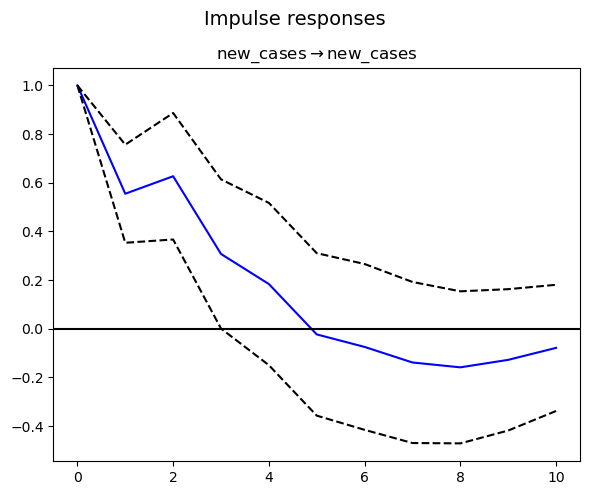

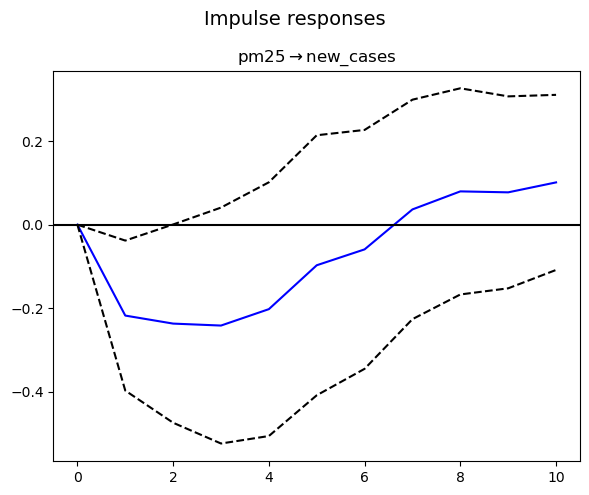

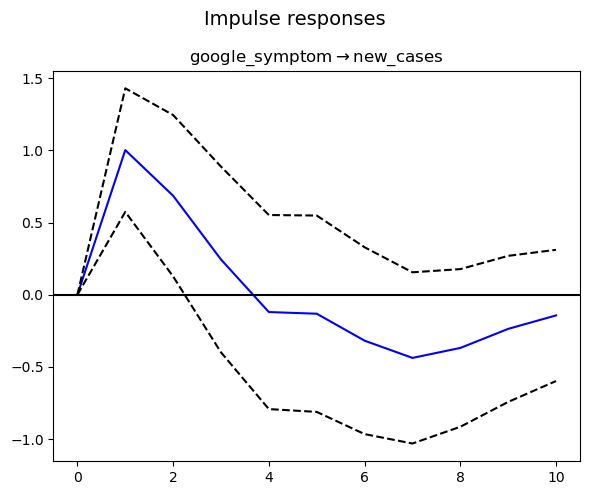

In [18]:
impulses = ['new_cases', 'pm25', 'google_symptom']
response = target  # e.g., 'cases'

for imp in impulses:
    irf.plot(impulse=imp, response=response, figsize=(6, 5))  # smaller plot size
    plt.tight_layout()

    


# Train Test split

Processing country: Chile
Processing country: Colombia
Processing country: Italy
Processing country: Mexico
Processing country: US


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequ

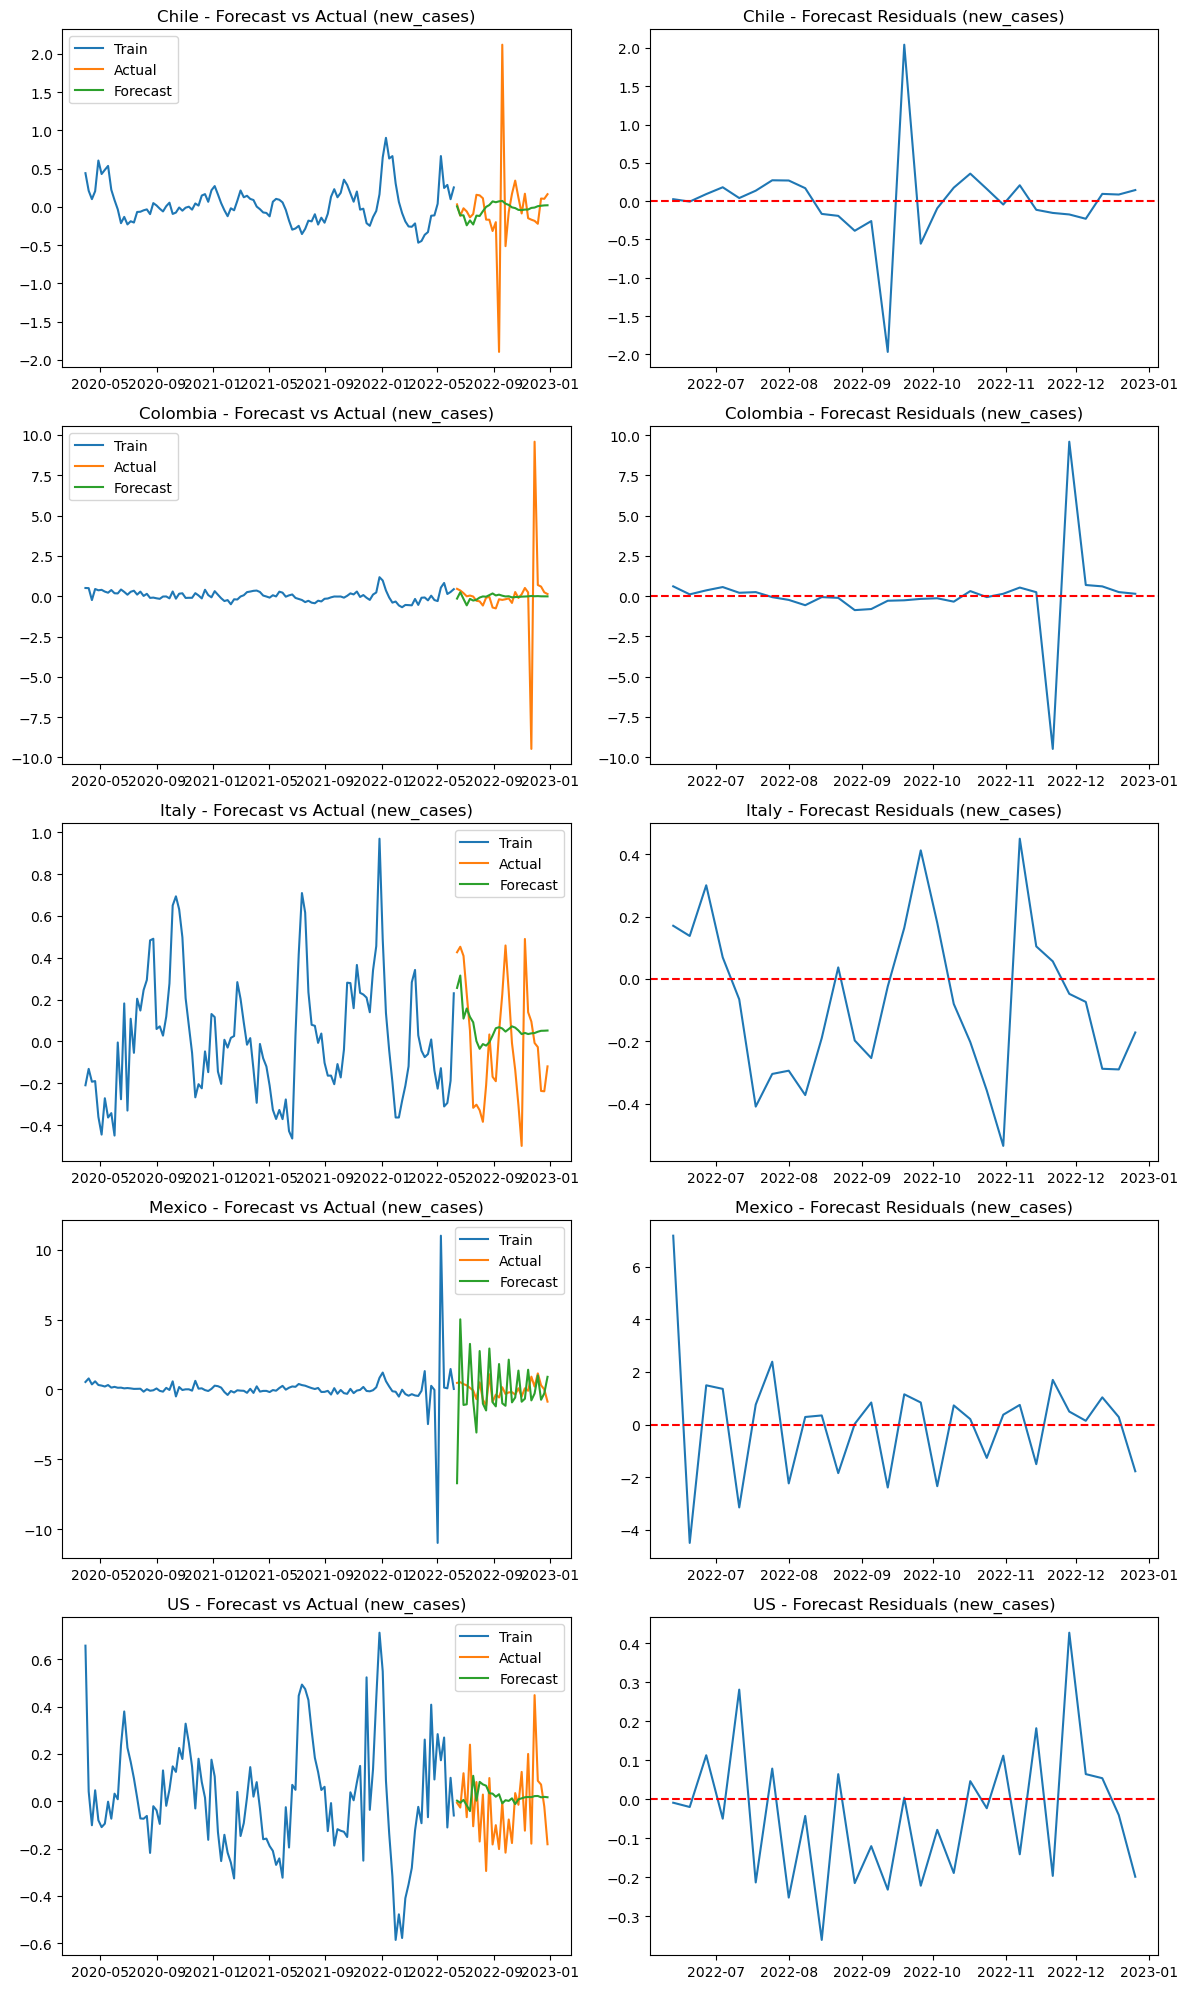

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

countries = df['country'].unique()

dict_metrics = {}
target = 'new_cases'

fig, axs = plt.subplots(len(countries), 2, figsize=(12, 4 * len(countries)))

for idx, country in enumerate(countries):
    print(f"Processing country: {country}")

    # filter by country
    df_var = df[df['country'] == country]

    # select columns
    df_var = df_var[['date', target, 'pm25', 'no2', 'o3', 'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average',
                      'pop_vaccinated', 'google_hospital', 'google_symptom']]
    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 0.1, inplace=True)

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_df = pd.DataFrame(forecast, index=df_test.index, columns=df_test.columns)

    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(df_test[target], forecast_df[target]))
    r2 = r2_score(df_test[target], forecast_df[target])

    dict_metrics[country] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable
    axs[idx, 0].plot(df_train[target], label='Train')
    axs[idx, 0].plot(df_test[target], label='Actual')
    axs[idx, 0].plot(forecast_df[target], label='Forecast')
    axs[idx, 0].set_title(f'{country} - Forecast vs Actual ({target})')
    axs[idx, 0].legend()

    # Plot residuals
    residuals = df_test[target] - forecast_df[target]
    axs[idx, 1].plot(residuals)
    axs[idx, 1].axhline(y=0, color='r', linestyle='--')
    axs[idx, 1].set_title(f'{country} - Forecast Residuals ({target})')

plt.tight_layout()
plt.show()

In [20]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df

,rmse,r2
Chile,0.565504,-0.027795
Colombia,2.534368,-0.006207
Italy,0.254726,0.161409
Mexico,2.093837,-12.486879
US,0.174970,-0.220746


Processing country: Chile
Processing country: Colombia
Processing country: Italy
Processing country: Mexico
Processing country: US


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequ

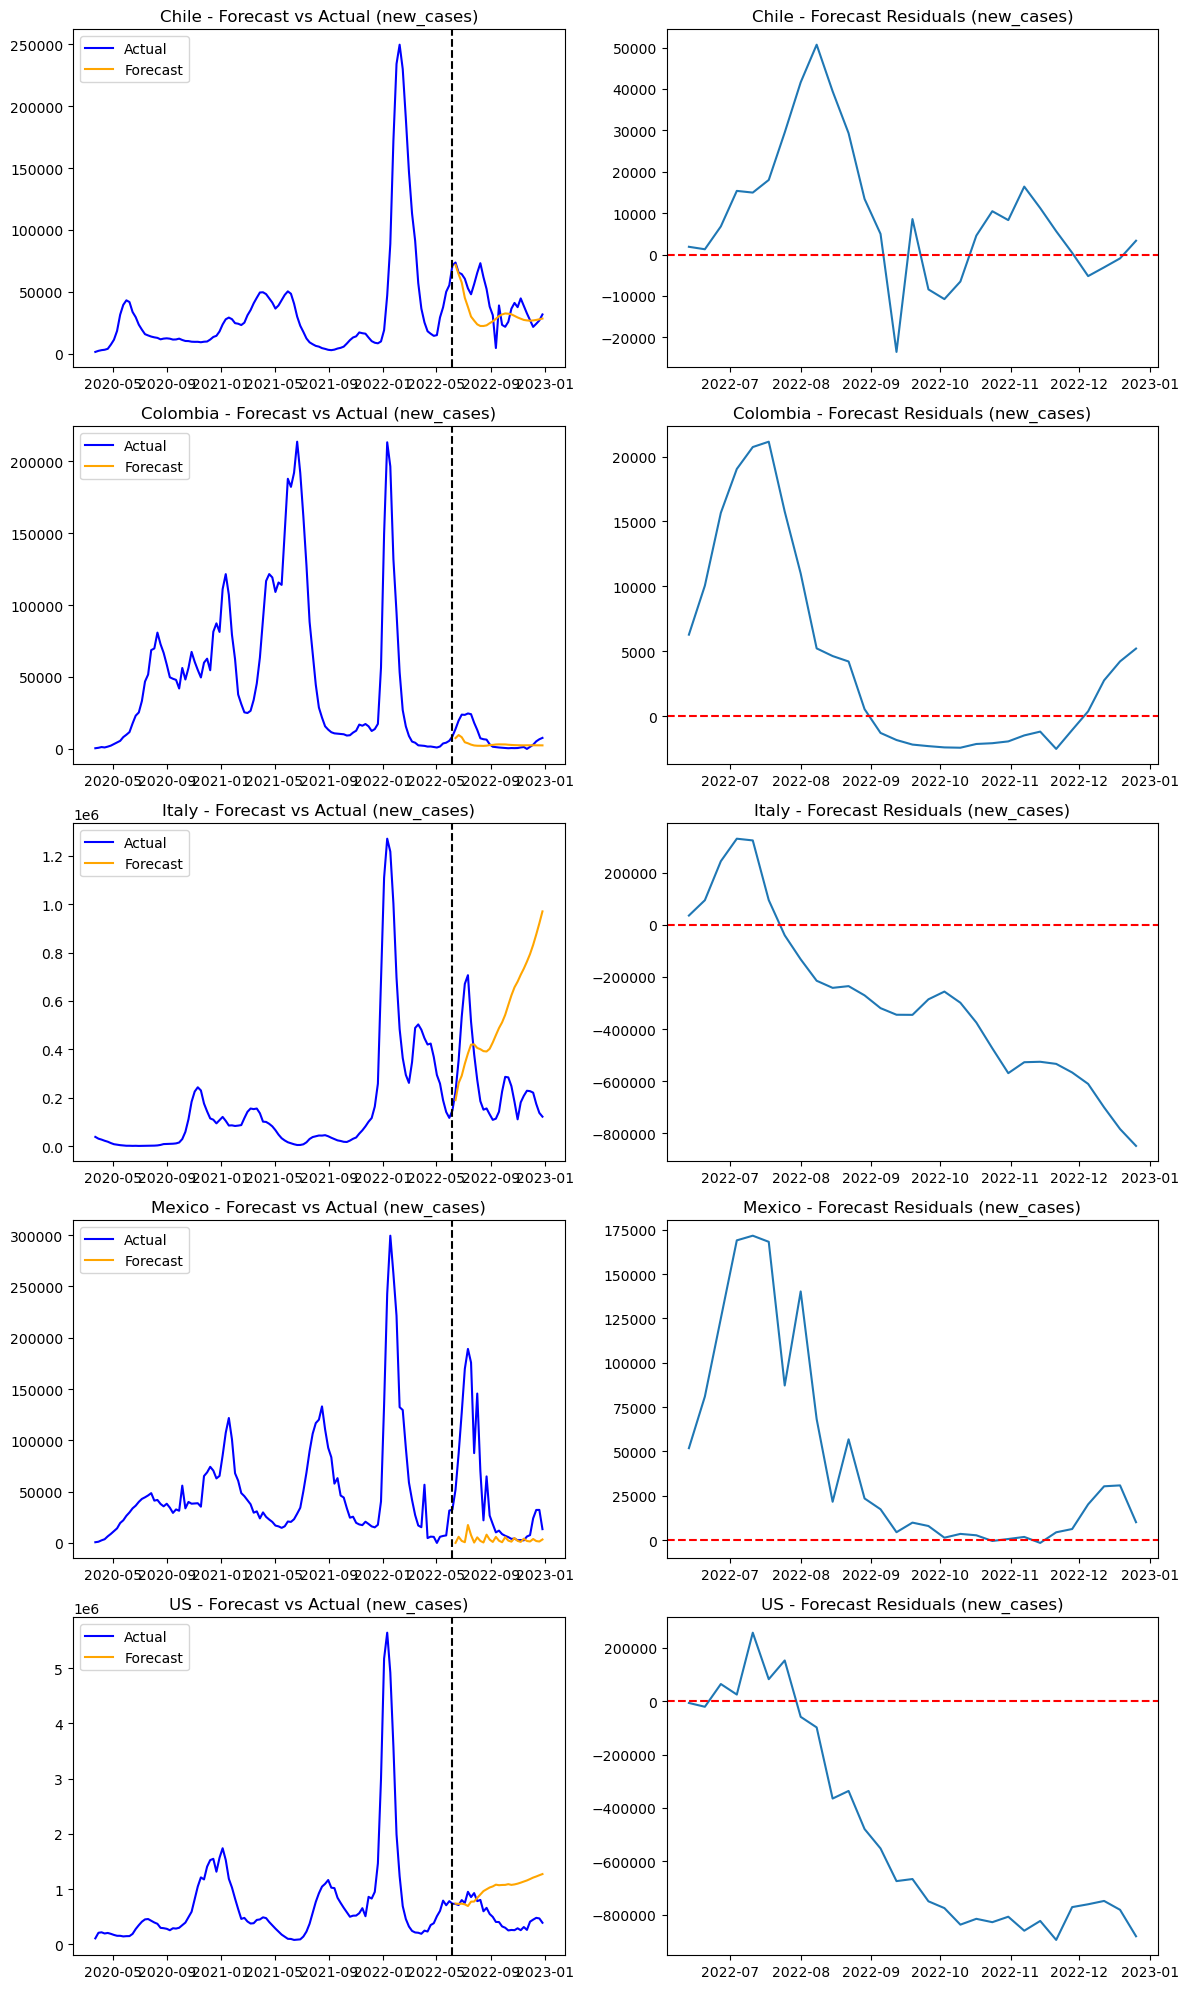

In [21]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

countries = df['country'].unique()

dict_metrics = {}
target = 'new_cases'

fig, axs = plt.subplots(len(countries), 2, figsize=(12, 4 * len(countries)))

for idx, country in enumerate(countries):
    print(f"Processing country: {country}")

    # filter by country
    df_var = df[df['country'] == country]

    # select columns
    df_var = df_var[['date', target, 'pm25', 'no2', 'o3', 'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average',
                      'pop_vaccinated', 'google_hospital', 'google_symptom']]
    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 0.1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[country] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx, 0].plot(df_original[target], label='Actual', color='blue')
    axs[idx, 0].plot(forecast_original_scale[target], label='Forecast', color='orange')
    axs[idx, 0].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx, 0].set_title(f'{country} - Forecast vs Actual ({target})')
    axs[idx, 0].legend()

    # Plot residuals in original scale
    residuals = actual_original_scale[target] - forecast_original_scale[target]
    axs[idx, 1].plot(residuals)
    axs[idx, 1].axhline(y=0, color='r', linestyle='--')
    axs[idx, 1].set_title(f'{country} - Forecast Residuals ({target})')

plt.tight_layout()
plt.show()

In [63]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df

,rmse,r2
Chile,5.067442e+06,-3.549428
Colombia,3.218298e+06,-66.684120
Italy,1.260053e+08,-77.734229
Mexico,8.664477e+06,-8.477963
US,2.995723e+08,-103.998640


Processing country: Chile
Processing country: Colombia
Processing country: Italy
Processing country: Mexico
Processing country: US


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequ

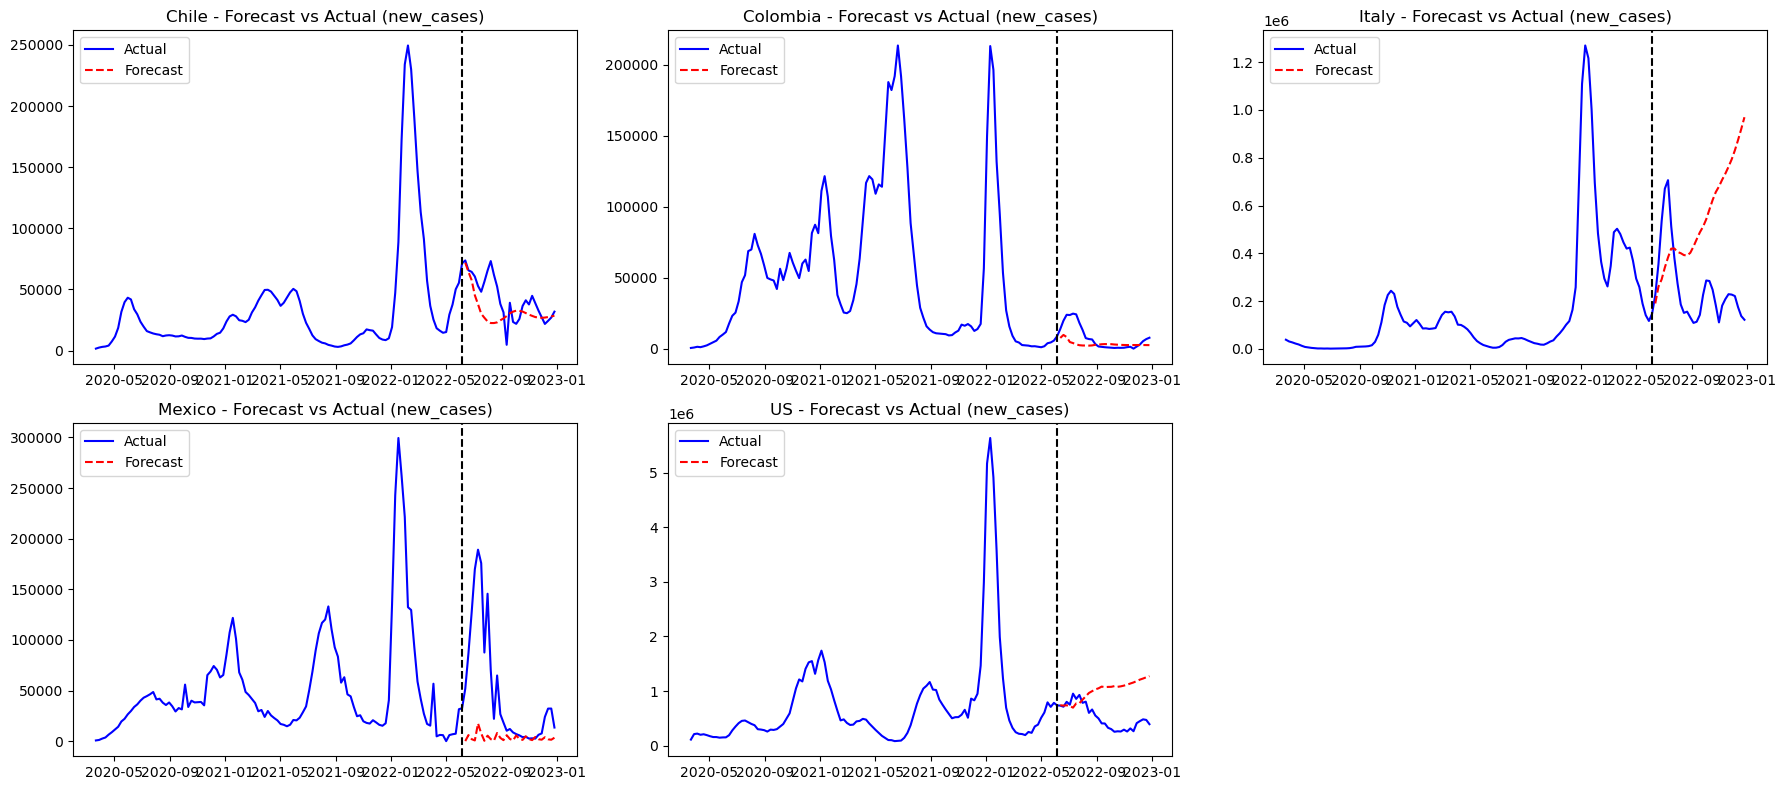

In [22]:
countries = df['country'].unique()

dict_metrics = {}
target = 'new_cases'

fig, axs = plt.subplots(2, 3, figsize=(18, 8))
axs = axs.flatten()

for idx, country in enumerate(countries):
    print(f"Processing country: {country}")

    # filter by country
    df_var = df[df['country'] == country]

    # select columns
    df_var = df_var[['date', target, 'pm25', 'no2', 'o3', 'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average',
                      'pop_vaccinated', 'google_hospital', 'google_symptom']]
    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 0.1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[country] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx].plot(df_original[target], label='Actual', color='blue')
    axs[idx].plot(forecast_original_scale[target], label='Forecast', color='red', linestyle='--')
    axs[idx].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx].set_title(f'{country} - Forecast vs Actual ({target})')
    axs[idx].legend()

# Adjust layout and remove any unused subplots
for j in range(len(countries), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [23]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df[['rmse']]

,rmse
Chile,18716.797720
Colombia,8640.392430
Italy,421870.604111
Mexico,72000.009790
US,616103.009998


## Feature Selection

Processing country: Chile
Index(['date', 'new_cases', 'google_symptom'], dtype='object')
Processing country: Colombia
Index(['date', 'new_cases', 'google_hospital', 'google_symptom'], dtype='object')
Processing country: Italy
Index(['date', 'new_cases', 'pm25', 'google_symptom'], dtype='object')
Processing country: Mexico
Index(['date', 'new_cases', 'google_symptom'], dtype='object')
Processing country: US
Index(['date', 'new_cases', 'StringencyIndex_Average', 'google_hospital'], dtype='object')


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequ

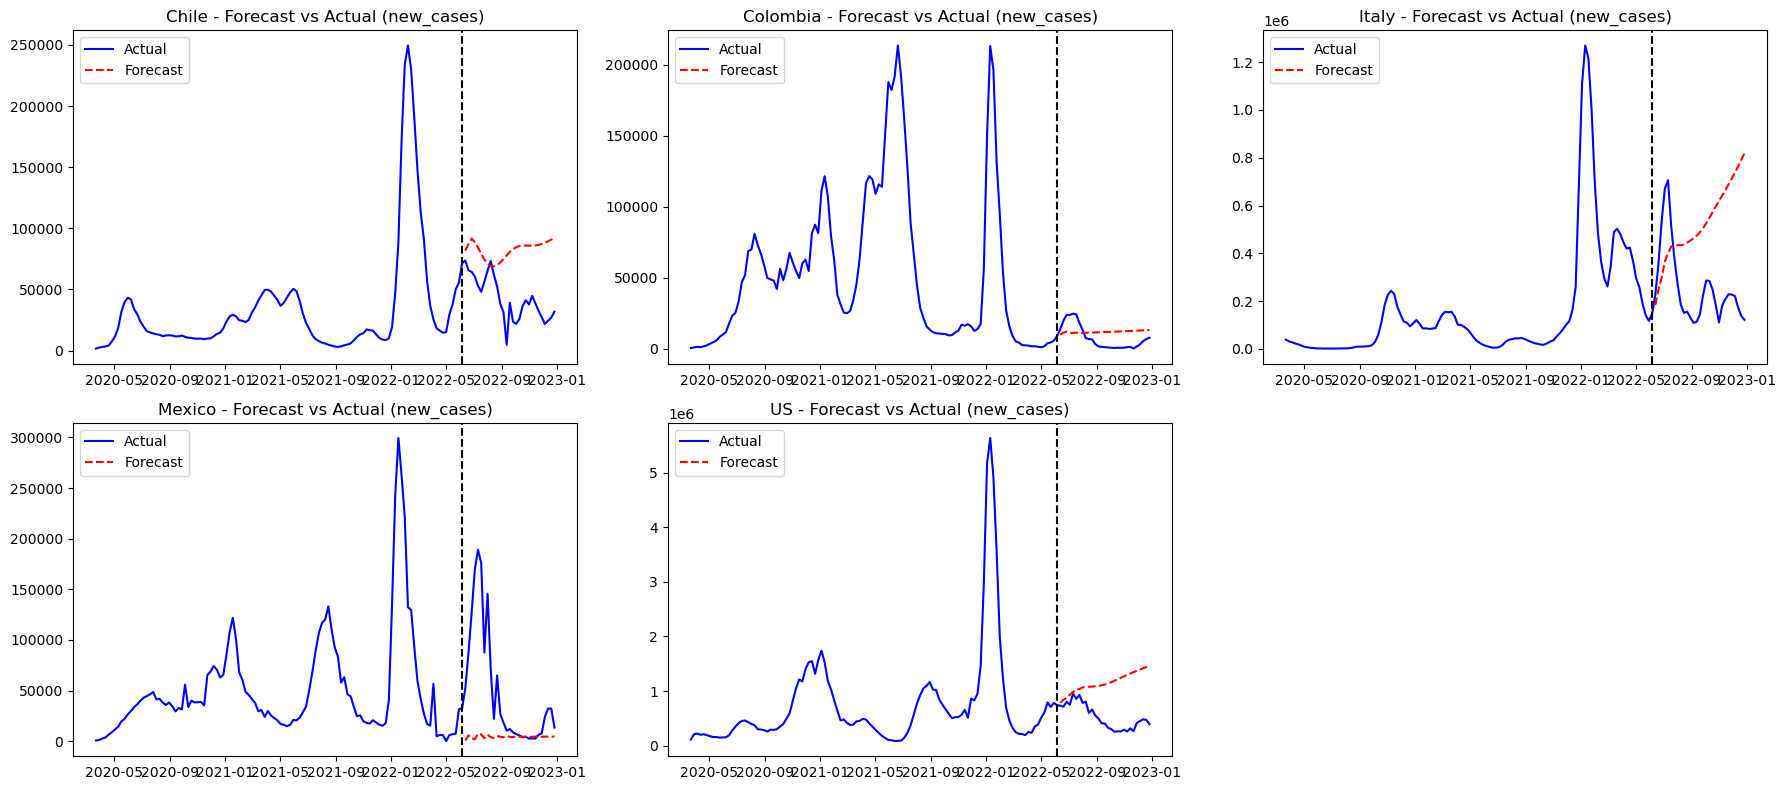

In [29]:
countries = df['country'].unique()

# Assuming dict_results from first code is already available with significant vars per country
dict_metrics = {}
target = 'new_cases'

fig, axs = plt.subplots(2, 3, figsize=(18, 8))
axs = axs.flatten()

for idx, country in enumerate(countries):
    print(f"Processing country: {country}")

    # filter by country
    df_var = df[df['country'] == country]

    # select columns based on significant variables
    significant_vars = dict_results[country]

    # Build list of variables for df_var dynamically, including only significant ones
    columns_to_use = ['date', target]  # always keep date and target

    # Add relevant original variables (without lag prefix)
    available_vars = ['pm25', 'no2', 'o3', 'Mean_distance_avg_14day_movavg', 
                      'StringencyIndex_Average', 'pop_vaccinated', 'google_hospital', 'google_symptom']

    for var in available_vars:
        if any(var in sig_var for sig_var in significant_vars):
            columns_to_use.append(var)

    # if columns_to_use less than 3, add google_symptom (self + date = 2)
    if len(columns_to_use) < 3:
        columns_to_use.append('google_symptom')

    df_var = df_var[columns_to_use]
    print(df_var.columns)

    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 0.1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    #print(df_train.columns)
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[country] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx].plot(df_original[target], label='Actual', color='blue')
    axs[idx].plot(forecast_original_scale[target], label='Forecast', color='red', linestyle='--')
    axs[idx].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx].set_title(f'{country} - Forecast vs Actual ({target})')
    axs[idx].legend()

# Adjust layout and remove any unused subplots
for j in range(len(countries), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()



In [30]:
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df[['rmse']]

,rmse
Chile,45284.353462
Colombia,9798.929078
Italy,377439.295507
Mexico,72476.752842
US,730183.793199


## Hybrid model

1. Fit a GGM on each country
2. Use that as a covariate 
3. Fit a VAR using the GGM fitted values as covariate
4. See the results